# Planck Scans — Batch Inference
Runs all real scans from `planck_scans/npy_scaled/` through the full pipeline
(backbone → transformer → coarse matching → morph decoder → Sinkhorn → LGR).
No ground truth — qualitative only. Dummy `gt_z=zeros` and `transform=eye`.

**Workflow:**
1. Run all scans once (inference + Chamfer) → stored in `results`
2. Summary table + bar chart
3. Pick a scan by name → open two O3D windows (before / after alignment)

In [1]:
# ── USER CONFIG ───────────────────────────────────────────────────────────────
SNAPSHOT  = 'epoch-30.pth.tar'  # checkpoint filename inside output/.../snapshots/
DEVICE    = 'cuda'

# Preprocessing for planck_scans/npy_scaled — scans are already in UHM meter-scale units.
# Only centering (subtract centroid) is applied. Flip Z if your scanner Z points away from face.
FLIP_Z  = False   # set True if scans arrive with Z pointing away from face
CENTER  = True    # subtract centroid to place scan at origin
# ─────────────────────────────────────────────────────────────────────────────

In [2]:
import os, sys, glob

EXP_DIR  = os.path.dirname(os.path.abspath('__file__'))
ROOT_DIR = os.path.dirname(os.path.dirname(EXP_DIR))
sys.path.insert(0, EXP_DIR)
sys.path.insert(0, ROOT_DIR)
os.chdir(EXP_DIR)

import torch
import numpy as np
import plotly.graph_objects as go
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from io import BytesIO
from IPython.display import Image, display

from geotransformer.modules.ops.transformation import apply_transform

from config_dowsampled import make_cfg
from dataset import train_valid_data_loader
from model import create_model

print('EXP_DIR :', EXP_DIR)
print('ROOT_DIR:', ROOT_DIR)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
EXP_DIR : /workspace/src/experiments/geotransformer.faces.stage4.gse.k3.max.oacl.stage2.sinkhorn
ROOT_DIR: /workspace/src


In [3]:
cfg = make_cfg()

_, _, neighbor_limits = train_valid_data_loader(
    cfg, distributed=False, val_aug_scale=1.0, val_aug_subsample=1.0
)
print('neighbor_limits:', neighbor_limits)

SNAP_DIR = os.path.join(
    ROOT_DIR, 'output',
    'geotransformer.facesdownsampledfixed.stage4.gse.k3.max.oacl.stage2.sinkhorn',
    'snapshots',
)
ckpt_path = os.path.join(SNAP_DIR, SNAPSHOT)

model = create_model(cfg).to(DEVICE)
model.neighbor_limits = neighbor_limits

ckpt = torch.load(ckpt_path, map_location=DEVICE)
sd   = ckpt.get('model', ckpt)
sd   = {k.replace('module.', ''): v for k, v in sd.items()}

missing = set(model.state_dict()) - set(sd)
extra   = set(sd) - set(model.state_dict())
if missing: print(f'[warn] missing keys (random init): {len(missing)}')
if extra:   print(f'[info] extra keys ignored         : {len(extra)}')

model.load_state_dict(sd, strict=False)
model.eval()

print(f'Loaded: {SNAPSHOT}  (epoch {ckpt.get("epoch", "?")})')
print(f'Keys matched: {len(set(sd) & set(model.state_dict()))} / {len(model.state_dict())}')

with torch.no_grad():
    mean_ref = model.generate_reference_geometry(torch.zeros(32, 100, device=DEVICE))
print(f'Mean ref: {mean_ref.shape}')

neighbor_limits: [60 24 29 31]
Loaded: epoch-30.pth.tar  (epoch 30)
Keys matched: 316 / 316
Mean ref: torch.Size([10788, 3])


In [4]:
def chamfer_distance(A, B, device=DEVICE):
    """Symmetric Chamfer distance (mean of bidirectional NN distances, metres)."""
    if isinstance(A, np.ndarray):
        A = torch.from_numpy(A).float().to(device)
    if isinstance(B, np.ndarray):
        B = torch.from_numpy(B).float().to(device)
    chunk = 2048
    dists_AB = [torch.cdist(A[i:i+chunk], B).min(dim=1).values for i in range(0, A.shape[0], chunk)]
    dists_BA = [torch.cdist(B[i:i+chunk], A).min(dim=1).values for i in range(0, B.shape[0], chunk)]
    return 0.5 * (torch.cat(dists_AB).mean().item() + torch.cat(dists_BA).mean().item())


def preprocess_scan(path, flip_z=FLIP_Z, center=CENTER, device=DEVICE):
    raw = np.load(path)
    pts = torch.from_numpy(raw[:, :3].astype(np.float32)).to(device)
    if flip_z:
        pts[:, 2] *= -1
    if center:
        pts -= pts.mean(dim=0, keepdim=True)
    return pts


def run_inference(src_pts, mean_ref, model, device=DEVICE):
    n_ref = mean_ref.shape[0]
    n_src = src_pts.shape[0]
    data_dict = {
        'points'   : torch.cat([mean_ref, src_pts], dim=0),
        'lengths'  : torch.tensor([n_ref, n_src], dtype=torch.int64),
        'features' : torch.ones(n_ref + n_src, 1, device=device),
        'gt_z'     : torch.zeros(32, 100, device=device),
        'transform': torch.eye(4, device=device),
    }
    with torch.no_grad():
        out = model(data_dict)
    return out


def pcd_trace(pts, color, name, size=2, opacity=0.7):
    if isinstance(pts, torch.Tensor):
        pts = pts.detach().cpu().numpy()
    return go.Scatter3d(
        x=pts[:, 0], y=pts[:, 1], z=pts[:, 2],
        mode='markers',
        marker=dict(size=size, color=color, opacity=opacity),
        name=name,
    )


def show_pcd(traces, title='', height=600):
    fig = go.Figure(data=traces)
    fig.update_layout(
        title=title, height=height,
        scene=dict(aspectmode='data'),
        legend=dict(itemsizing='constant'),
        margin=dict(l=0, r=0, b=0, t=40),
    )
    fig.show()

---
## Run all scans (inference + Chamfer)

In [5]:
SCANS_DIR = os.path.join(ROOT_DIR, 'planck_scans', 'npy_scaled')
scan_paths = sorted(
    glob.glob(os.path.join(SCANS_DIR, '*.npy')),
    key=lambda p: int(''.join(filter(str.isdigit, os.path.basename(p))) or '0'),
)
print(f'Found {len(scan_paths)} scans in {SCANS_DIR}')
for p in scan_paths:
    print(' ', os.path.basename(p))

Found 20 scans in /workspace/src/planck_scans/npy_scaled
  planck_1.npy
  planck_2.npy
  planck_3.npy
  planck_4.npy
  planck_5.npy
  planck_6.npy
  planck_7.npy
  planck_8.npy
  planck_9.npy
  planck_10.npy
  planck_11.npy
  planck_12.npy
  planck_13.npy
  planck_14.npy
  planck_15.npy
  planck_16.npy
  planck_17.npy
  planck_18.npy
  planck_19.npy
  planck_20.npy


In [6]:
results = {}  # name -> result dict

for scan_path in scan_paths:
    scan_name = os.path.basename(scan_path)
    try:
        src_pts = preprocess_scan(scan_path)
        out     = run_inference(src_pts, mean_ref, model)

        morphed_ref = out['morphed_full']
        est_tf      = out['estimated_transform']
        src_model   = out['src_points']
        src_aligned = apply_transform(src_model, est_tf)

        cd = chamfer_distance(src_aligned, morphed_ref)

        results[scan_name] = {
            'name'        : scan_name,
            'src_raw'     : src_pts.cpu().numpy(),
            'src_aligned' : src_aligned.cpu().numpy(),
            'morphed_ref' : morphed_ref.cpu().numpy(),
            'mean_ref'    : mean_ref.cpu().numpy(),
            'chamfer'     : cd,
            'n_src'       : src_pts.shape[0],
            'error'       : None,
        }
        print(f'  {scan_name:20s}  {src_pts.shape[0]:5d} pts  CD={cd:.4f} m')

    except Exception as e:
        print(f'  {scan_name:20s}  ERROR: {e}')
        results[scan_name] = {'name': scan_name, 'error': str(e), 'chamfer': float('nan')}

print(f'\nDone — {sum(r["error"] is None for r in results.values())}/{len(results)} succeeded')

  planck_1.npy           2000 pts  CD=0.3307 m
  planck_2.npy           2000 pts  CD=0.1191 m
  planck_3.npy           2000 pts  CD=0.1132 m
  planck_4.npy           2000 pts  CD=0.1377 m
  planck_5.npy           2000 pts  CD=0.4273 m
  planck_6.npy           2000 pts  CD=0.3510 m
  planck_7.npy           2000 pts  CD=0.3518 m
  planck_8.npy           2000 pts  CD=0.1166 m
  planck_9.npy           2000 pts  CD=0.3523 m
  planck_10.npy          2000 pts  CD=0.3434 m
  planck_11.npy          2000 pts  CD=0.3353 m
  planck_12.npy          2000 pts  CD=0.4391 m
  planck_13.npy          2000 pts  CD=0.4417 m
  planck_14.npy          2000 pts  CD=0.3299 m
  planck_15.npy          2000 pts  CD=0.1512 m
  planck_16.npy          2000 pts  CD=0.3713 m
  planck_17.npy          2000 pts  CD=0.1112 m
  planck_18.npy          2000 pts  CD=0.3591 m
  planck_19.npy          2000 pts  CD=0.3468 m
  planck_20.npy          2000 pts  CD=0.3589 m

Done — 20/20 succeeded


---
## Summary statistics

In [7]:
ok     = [r for r in results.values() if r['error'] is None]
cd_vals = np.array([r['chamfer'] for r in ok])

print('=' * 52)
print(f'{"Scan":<22}  {"n_pts":>6}  {"Chamfer (m)":>12}')
print('-' * 52)
for r in results.values():
    if r['error'] is None:
        print(f"{r['name']:<22}  {r['n_src']:>6}  {r['chamfer']:>12.4f}")
    else:
        print(f"{r['name']:<22}  {'ERROR':>20}  {r['error']}")
print('=' * 52)
print(f"{'mean':<22}  {'':>6}  {cd_vals.mean():>12.4f}")
print(f"{'median':<22}  {'':>6}  {np.median(cd_vals):>12.4f}")
print(f"{'std':<22}  {'':>6}  {cd_vals.std():>12.4f}")
print(f"{'min':<22}  {'':>6}  {cd_vals.min():>12.4f}")
print(f"{'max':<22}  {'':>6}  {cd_vals.max():>12.4f}")

Scan                     n_pts   Chamfer (m)
----------------------------------------------------
planck_1.npy              2000        0.3307
planck_2.npy              2000        0.1191
planck_3.npy              2000        0.1132
planck_4.npy              2000        0.1377
planck_5.npy              2000        0.4273
planck_6.npy              2000        0.3510
planck_7.npy              2000        0.3518
planck_8.npy              2000        0.1166
planck_9.npy              2000        0.3523
planck_10.npy             2000        0.3434
planck_11.npy             2000        0.3353
planck_12.npy             2000        0.4391
planck_13.npy             2000        0.4417
planck_14.npy             2000        0.3299
planck_15.npy             2000        0.1512
planck_16.npy             2000        0.3713
planck_17.npy             2000        0.1112
planck_18.npy             2000        0.3591
planck_19.npy             2000        0.3468
planck_20.npy             2000        0.3589
me

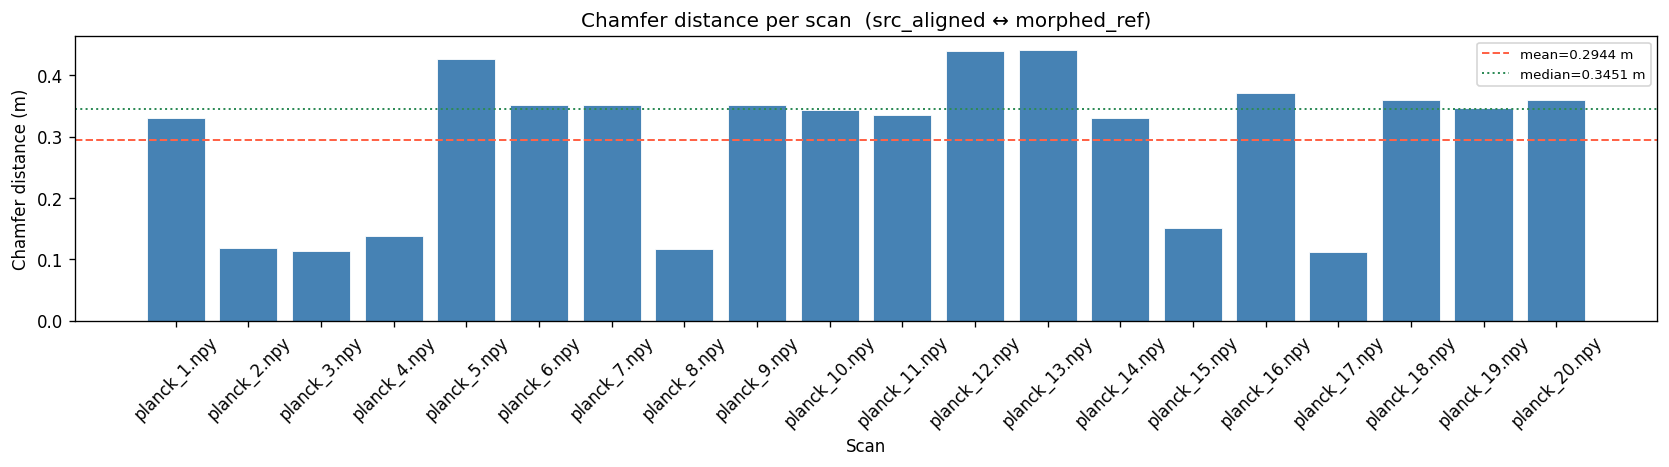

In [8]:
fig, ax = plt.subplots(figsize=(max(6, len(ok) * 0.7), 4))
ax.bar([r['name'] for r in ok], [r['chamfer'] for r in ok],
       color='steelblue', edgecolor='white', linewidth=0.5)
ax.axhline(cd_vals.mean(),     color='tomato',   linestyle='--', linewidth=1.2,
           label=f'mean={cd_vals.mean():.4f} m')
ax.axhline(np.median(cd_vals), color='seagreen', linestyle=':',  linewidth=1.2,
           label=f'median={np.median(cd_vals):.4f} m')
ax.set_xlabel('Scan')
ax.set_ylabel('Chamfer distance (m)')
ax.set_title('Chamfer distance per scan  (src_aligned ↔ morphed_ref)')
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=8)
plt.tight_layout()

buf = BytesIO()
fig.savefig(buf, format='png', dpi=120, bbox_inches='tight')
plt.close(fig)
buf.seek(0)
display(Image(buf.read()))

---
## Open3D visualization — pick a scan
Set `VIZ_SCAN` to any scan name from the table above, then run the next cell.
Two inline Plotly figures render in the notebook:
- **Plot 1:** mean ref (blue) + raw scan (red) — *before* alignment
- **Plot 2:** morphed ref (blue) + aligned scan (orange) — *after* alignment

In [30]:
VIZ_SCAN = 'planck_1.npy'   # ← change this to any scan name from the table above

print('Available scans:')
for name, r in results.items():
    tag = f"CD={r['chamfer']:.4f} m" if r['error'] is None else f"ERROR: {r['error']}"
    marker = '  ◀' if name == VIZ_SCAN else ''
    print(f'  {name:<22}  {tag}{marker}')

Available scans:
  planck_1.npy            CD=0.3307 m  ◀
  planck_2.npy            CD=0.1191 m
  planck_3.npy            CD=0.1132 m
  planck_4.npy            CD=0.1377 m
  planck_5.npy            CD=0.4273 m
  planck_6.npy            CD=0.3510 m
  planck_7.npy            CD=0.3518 m
  planck_8.npy            CD=0.1166 m
  planck_9.npy            CD=0.3523 m
  planck_10.npy           CD=0.3434 m
  planck_11.npy           CD=0.3353 m
  planck_12.npy           CD=0.4391 m
  planck_13.npy           CD=0.4417 m
  planck_14.npy           CD=0.3299 m
  planck_15.npy           CD=0.1512 m
  planck_16.npy           CD=0.3713 m
  planck_17.npy           CD=0.1112 m
  planck_18.npy           CD=0.3591 m
  planck_19.npy           CD=0.3468 m
  planck_20.npy           CD=0.3589 m


In [31]:
r = results.get(VIZ_SCAN)
assert r is not None,  f'{VIZ_SCAN!r} not found in results — check the name'
assert r['error'] is None, f'{VIZ_SCAN} failed inference: {r["error"]}'

cd = r['chamfer']
print(f'Visualising: {VIZ_SCAN}  ({r["n_src"]} pts)  CD={cd:.4f} m')

# ── Before alignment ──────────────────────────────────────────────────────────
show_pcd(
    [pcd_trace(r['mean_ref'], 'steelblue', 'mean ref'),
     pcd_trace(r['src_raw'],  'tomato',    f'raw scan ({r["n_src"]} pts)')],
    title=f'{VIZ_SCAN} — Before alignment',
)

# ── After alignment ───────────────────────────────────────────────────────────
show_pcd(
    [pcd_trace(r['morphed_ref'], 'steelblue', 'morphed ref'),
     pcd_trace(r['src_aligned'], 'orange',    f'aligned scan  CD={cd:.4f} m')],
    title=f'{VIZ_SCAN} — After alignment',
)

# ── Morph quality ─────────────────────────────────────────────────────────────
show_pcd(
    [pcd_trace(r['mean_ref'],    'steelblue', 'mean ref'),
     pcd_trace(r['morphed_ref'], 'orange',  'morphed ref (pred z)')],
    title=f'{VIZ_SCAN} — Morph quality',
)

Visualising: planck_1.npy  (2000 pts)  CD=0.3307 m
